<a href="https://colab.research.google.com/github/CharalapML/ColabCode/blob/main/Galileos%20Pendulum_-One%20dimensional%20A01_DO_NOT_ALTER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Based on work on youtube by Mr P. Solver

Position  on 1D path

Parabola :   $x =(\theta)$ and $y= \theta$

Simple Pendulum: $x = lsin(\theta)$ and $y = -lcos(\theta)$, where $l$ = length of pendulum

Kinetic energy:  $T = \frac{1}{2}m ({\dot x}^2 + {\dot y}^2)$ , where $\large\dot x = \frac{dx}{dt}  $  and $\large\dot y = \frac{dy}{dt}  $

Potential Energy: $V = mgy$

The Lagrangian: $L ({d\theta},{d\dot \theta}, {t)}  = T - V$

Lagranges Eqn:  $\large\frac{dL}{d\theta} - \frac{d}{dt}\frac{dL}{d\dot \theta} = 0$ , where $\large\dot\theta = \frac{d\theta}{dt}  $

So

$\large\frac{dL}{d\theta} = \frac{d}{dt}\frac{dL}{d\dot \theta} $     $i.e.   \large lhs = rhs $

In [1]:
import numpy as np
import sympy as sp
from sympy.utilities import lambdify
from sympy.solvers import solve
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import PillowWriter
from IPython.display import HTML

In [2]:
class Pendulum:
  def __init__(self, l, t, theta0, v0):  #theta0 = starting angle, v0 = starting velocity
    self.l = l
    self.t = t
    self.conds = [theta0, v0]

  def SolvePendulum(self):
    # m = mass, g = gravity (=9.81m/s), l = length of pendulum, t = time
    m,g,l,t = sp.symbols('m g l t')
    theta = sp.Function('theta')(t)
    #display(theta)
    dtheta  = theta.diff(t)   # velocity
    ddtheta = dtheta.diff(t)  # acceleration

    x,y = l*sp.sin(theta), -l*sp.cos(theta)

    T = sp.Rational(1,2) * m * (x.diff(t)**2 + y.diff(t)**2)
    V = m*g*y
    L = T-V

    display(L.simplify())

    lhs = L.diff(theta)
    rhs = sp.diff(L.diff(dtheta), t)

    eq = rhs - lhs
    #display(eq)
    eq = sp.solve(eq, ddtheta)[0]
    display(eq.simplify())

    dthetadt_num =sp.lambdify(dtheta, dtheta)
    dudt_num  = sp.lambdify((g, l, theta), eq)

    x_num, y_num = sp.lambdify((l, theta), x), sp.lambdify((l,theta), y)
    # x_num, y_num are 𝑙𝑠𝑖𝑛(𝜃) and 𝑦= -𝑙𝑐𝑜𝑠(𝜃)

    del m,g,l,t

    g = 9.81
    l = self.l
    t = self.t
    conds =self.conds

    def dXdt(X,t,g,l):
      theta_num, u_num = X

      return [dthetadt_num(u_num),
              dudt_num(g,l,theta_num)]

    sol = odeint(dXdt, t=t, y0=conds, args=(g,l))
    angle = sol.T[0] # ie theta
    velocity = sol.T[1]

    return x_num(l,angle), y_num(l,angle), sol  # sol.T,


# **Need a for loop in next cell**

In [3]:
t = np.linspace(0,100,5000)

length = [1.0, 1.38268, 1.70711, 1.92388, 2.0, 1.92388, 1.70711, 1.38268, 1.0, 1.38268, 1.70711, 1.92388, 2.0, 1.92388, 1.70711, 1.38268]
pendlist =['pend', 'pend1', 'pend2', 'pend3', 'pend4', 'pend5', 'pend6', 'pend7', 'pend8', 'pend9', 'pend10', 'pend11', 'pend12', 'pend13', 'pend14', 'pend15']
Zpoint = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0]

xlist = ['x', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15']
ylist = ['y', 'y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'y7', 'y8', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14', 'y15']
sollist = ['sol', 'sol1', 'sol2', 'sol3','sol4', 'sol5', 'sol6', 'sol7', 'sol8', 'sol9', 'sol10', 'sol11','sol12', 'sol13', 'sol14', 'sol15']

xa = []
ya = []
sola = []

for p, l, x, y, sol in zip (pendlist, length, xlist, ylist, sollist):
  p = Pendulum(l, t, np.pi/2, 0)
  x,y,sol = p.SolvePendulum()
  xa.append(x)
  ya.append(y)
  sola.append(sol)

# pend = Pendulum(1, t, np.pi/2, 0)
# #pend.SolvePendulum()
# #sol = pend.SolvePendulum()
# x,y,sol = pend.SolvePendulum()

# pend1 = Pendulum(0.5, t, -np.pi/2, 0)
# #pend.SolvePendulum()
# #sol = pend.SolvePendulum()
# x1,y1,sol1 = pend1.SolvePendulum()

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

-g*sin(theta(t))/l

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

-g*sin(theta(t))/l

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

...

-g*sin(theta(t))/l

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

-g*sin(theta(t))/l

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

-g*sin(theta(t))/l

The period T of a pendulum with a cord length L is given by the formula T = 2π√(L/g)

2, π and g constants so the determining variable is √(L)


In [4]:
# Create a sequence of numbers from A to B (inclusive) with a step of 1
A = 5
B = 15
sequence = np.arange(A, B+1, 1)  # NB  -1 if sequence goes from high to low

# Reverse the sequence and exclude the last (highest or lowest number)
reversed_sequence = sequence[-2::-1]

# Concatenate the two sequences
Seq = np.hstack((sequence, reversed_sequence))#.shape

sequence
reversed_sequence
Seq
lenseq =len(Seq)
lenseq

21

In [5]:
Seq[20]

np.int64(5)

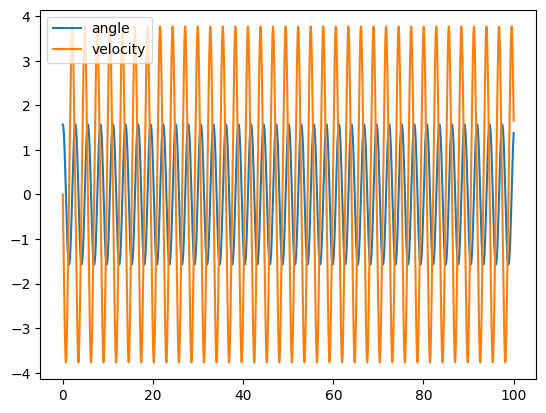

In [7]:
theta = sol.T[0]
velocity = sol.T[1]

plt.plot(t, theta, label ='angle')
plt.plot(t, velocity, label = 'velocity')
plt.legend()

In [8]:
# plt.plot(t,x1)

In [10]:
for l in range (Seq[0],Seq[lenseq-1]):
  t = np.linspace(0,10,500)


# **Need for loop for the next cell**

1.0 -6.123233995736766e-17
1.38268 -8.466473181225311e-17
1.70711 -1.045303398646219e-16
1.92388 -1.1780367419718049e-16
2.0 -1.2246467991473532e-16
1.92388 -1.1780367419718049e-16
1.70711 -1.045303398646219e-16
1.38268 -8.466473181225311e-17
1.0 -6.123233995736766e-17
1.38268 -8.466473181225311e-17
1.70711 -1.045303398646219e-16
1.92388 -1.1780367419718049e-16
2.0 -1.2246467991473532e-16
1.92388 -1.1780367419718049e-16
1.70711 -1.045303398646219e-16
1.38268 -8.466473181225311e-17


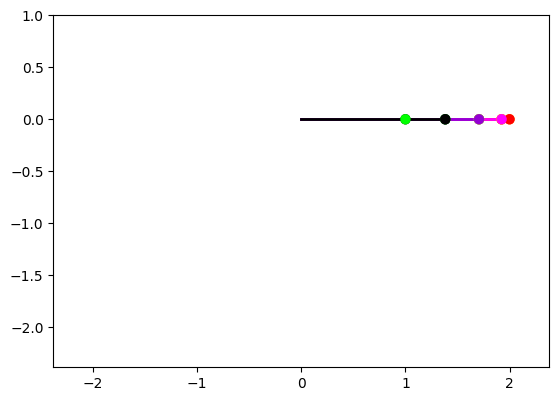

In [12]:

x0list = [xa[0][0], xa[1][0], xa[2][0], xa[3][0], xa[4][0], xa[5][0], xa[6][0], xa[7][0], xa[8][0], xa[9][0], xa[10][0], xa[11][0], xa[12][0], xa[13][0], xa[14][0], xa[15][0] ]
y0list = [ya[0][0], ya[1][0], ya[2][0], ya[3][0], ya[4][0], ya[5][0], ya[6][0], ya[7][0], ya[8][0], ya[9][0], ya[10][0], ya[11][0], ya[12][0], ya[13][0], ya[14][0], ya[15][0] ]

# x0list = [xa[i][0] for i in range(len(xa))]
# y0list = [ya[i][0] for i in range(len(ya))]

#linelist = ['line', 'line1', 'line2', 'line3']
colours  = ['black', 'darkviolet', 'magenta', 'red', 'orange', 'yellow', 'lime', 'limegreen', 'lime', 'green', 'yellow', 'orange', 'red', 'magenta', 'darkviolet', 'black' ]

# Store Line2D and Circle objects in lists
lines = []
circles = []
bobradius = 0.05

fig = plt.figure()
ax = fig.add_subplot(aspect = 'equal')

for x0, y0, col in zip(x0list, y0list, colours):
  # x0,y0 = x[0],y[0]

  line, = ax.plot([0,x0],[0,y0], lw = 2, c = col)
  lines.append(line)
  circle = ax.add_patch(plt.Circle((x0,y0), bobradius, fc=col,zorder = 3))
  circles.append(circle)
  ax.set_xlim(-x.max()-1.0,x.max()+1.0)
  ax.set_ylim(y.min()-1.0,1.0)
  print(x0,y0)

  #print(ll)

def animate(i):
  for ll, cl,xaa, yaa in zip(lines, circles, xa, ya):
    ll.set_data([0,xaa[i]],[0,yaa[i]])
    cl.center = xaa[i], yaa[i]

steps = len(x)
frames = steps
dt = t[1] - t[0]
interval = dt*10000
# ani = animation.FuncAnimation(fig, animate, frames = steps, interval = interval, repeat = True)
# ani.save('pen.gif', writer = 'pillow', fps = 50)

ani = animation.FuncAnimation(fig, animate, frames = steps, interval = interval, repeat = True) # frames = 100*len(t))
ffmpeg_writer = animation.FFMpegWriter(fps=50)
ani.save('Pendulum1.mp4', writer = ffmpeg_writer)

In [13]:
STOP

NameError: name 'STOP' is not defined

In [ ]:
 # t = np.linspace(0,10,500)
# pend = Pendulum(1,t,np.pi/2,0)
# sol = pend.SolvePendulum()
# x,y = pend.SolvePendulum()

In [ ]:
# t = np.linspace(0,10,500)
# l = np.linspace(5,15,1)
# pend = Pendulum(1,t,np.pi/2,0)
# sol = pend.SolvePendulum()
# x,y = pend.SolvePendulum()

In [ ]:
t = np.linspace(0,10,1000)
pend = {}
sol = {}
x = {}
y = {}
for k in range(5, 16, 1):
  pend[k] = Pendulum((k*1*0.1),t,np.pi/2, 0)
  sol[k] = pend[k].SolvePendulum()
  x[k],y[k] = pend[k].SolvePendulum()


### **Set a mirrored sequence of numbers that will be the lengths of the pendulums**

Colours for the bobs: 'purple', 'magenta', 'red', 'orange', 'yellow', 'light green', 'green', 'teal', 'blue', 'violet', 'silver'

NB if the number of pendulums increase/decrease then the colours will need to be added to or reduced

for colours see https://matplotlib.org/stable/gallery/color/named_colors.html

In [ ]:
colours = ['darkviolet', 'magenta', 'red', 'orange', 'yellow', 'lime', 'limegreen', 'teal', 'blue', 'deepskyblue', 'cyan']

# Reverse the colour sequence and exclude the last colour
reversed_colours = colours[-2::-1]

# Concatenate the two sequences
ColSeq = np.hstack((colours, reversed_colours))#.shape
lenColSeq = len(ColSeq)
lenColSeq
ColSeq

In [ ]:

from matplotlib.patches import Rectangle
fig, ax = plt.subplots()

#create simple line plot
ax.plot([2, 1],[2, 1])
for j in range(len(ColSeq)):
  #add rectangle to plot
  ax.add_patch(Rectangle((j+1, 1), 1, 1,
              edgecolor = ColSeq[j],
              facecolor = ColSeq[j],
              fill=True,
              lw=1))
  # print(ColSeq[j])
  # print (j)

#display plot
plt.show()

In [ ]:
# RUN THIS
# theta = sol[5][0]
# velocity = sol[15][1]

# # plt.plot(t,theta, label = 'angle')
# # plt.plot(t,velocity, label = 'velocity')
# plt.plot(t,x[5])
# plt.legend()

In [ ]:
print(len(x))

Equations  in vector Matrix form



In [ ]:
animate(499)

In [ ]:
STOP

In [ ]:
x0,y0 = x[0],y[0]

fig = plt.figure()
ax = fig.add_subplot(aspect = 'equal')

line , = ax.plot([0,x0],[0,y0], lw = 1, c = 'black')
bobradius = 0.05
circle = ax.add_patch(plt.Circle((x0,y0),bobradius, fc='r',zorder = 3))
ax.set_xlim(-x.max()-0.5,x.max()+0.5)
ax.set_ylim(y.min()-0.5,0.5)

def animate(i):
  line.set_data([0,x[k][i]],[0,y[k][i]])
  circle.center = x[k][i], y[k][i]

steps = len(x)
frames = steps
dt = t[1] - t[0]
interval = dt*1000
# ani = animation.FuncAnimation(fig, animate, frames = steps, interval = interval, repeat = True)
# ani.save('pen.gif', writer = 'pillow', fps = 50)

ani = animation.FuncAnimation(fig, animate, frames = steps, interval = interval, repeat = True) # frames = 100*len(t))
ffmpeg_writer = animation.FFMpegWriter(fps=50)
ani.save('Pendulum.mp4', writer = ffmpeg_writer)

In [ ]:
STOP

In [ ]:
t,m,g = smp.symbols('t m g')
the = smp.symbols(r'\theta', cls=smp.Function)
omega = smp.symbols(r'\omega', cls=smp.Function)
the = the(t)
the_d = smp.diff(the,t)
omega = the_d
the_dd = smp.diff(the_d,t)
l = smp.symbols('l')

In [ ]:
the

In [ ]:
x,y =smp.symbols('x y', cls=smp.Function)
x =x(the)
y =y(the)

In [ ]:
x

Define x and y

In [ ]:
# path = 'parabola'
# if path == 'parabola':
#   x = the
#   y = the**2
#   x_f = smp.lambdify(the, x)
#   y_f = smp.lambdify(the, y)

In [ ]:
path = 'Simple'
if path == 'Simple':
  x = smp.sin(the)
  y = smp.cos(the)
  x_f = smp.lambdify(the, x)
  y_f = smp.lambdify(the, y)

In [ ]:
y_f(2)

Define T, V , and L

In [ ]:
T = 1/2 * m * (smp.diff(x,t)**2 + smp.diff(y,t)**2)
V = m*g*y
L = T-V

In [ ]:
L
Lsimplify = L.simplify()
Lsimplify

Legrange Equation

In [ ]:
LE = smp.diff(L,the) - smp.diff(smp.diff(L, the_d), t)
LEsimplify = LE.simplify()  # simplifies the LE equation

In [ ]:
LEsimplify

Solve for \frac{dv{\theta)}{dt} = \omega  and \frac{d^2 u}{dx^2} so we can solve it with an ODE Solver. Our system of equtions are

d $$ r'\theta

In [ ]:
deriv_2 = smp.solve(LE,the_dd)[0]
deriv_1 = the_d

In [ ]:
deriv_2

Convert into a niumpy exopression

In [ ]:
deriv2_f = smp.lambdify((g, the, the_d), deriv_2)
deriv1_f = smp.lambdify(the_d, the_d)

In [ ]:
deriv2_f(2,2,2)

In [ ]:
S = (theta, omega)  #at 13:39 minutes

In [ ]:
S

Create ODE

In [ ]:
def dSdt(S,t):
  return[
      deriv1_f(S[1]), # dtheta/dt
      deriv2_f(g,S[0],S[1])  # domega/dt
        ]

Solve

In [ ]:
t = np.linspace(0,20,1000)
g = 9.81
ans1 = odeint(dSdt, y0 =[0.9,0],t=t)
ans2 = odeint(dSdt, y0 =[1,0],t=t)

In [ ]:
ans1

In [ ]:
plt.plot(t, ans1.T[0])
plt.plot(t, ans2.T[0])

17:20 minutes

In [ ]:
def get_xy(theta):
  return x_f(theta), y_f(theta)

In [ ]:
x1, y1 = get_xy(ans1.T[0])
x2, y2 = get_xy(ans2.T[0])

In [ ]:
print(x1, y1)
# print()
# print(x2, y2)

In [ ]:
def animate(i):
  # line1.set_data([x1[i]], [y1[i]])
  # line2.set_data([x2[i]], [y2[i]])
  line1.set_data([0, x1[i]], [0, y1[i]])
  # line2.set_data([0,x2[i]], [0,y2[i]])
  return line1 #, line2

fig, ax = plt.subplots(1,1)
ax.grid()
line1 = plt.plot([],[],'ro')
# line2 = plt.plot([],[],'ro')
ax.set_ylim(-1,16)
ax.set_xlim(-4,4)
ani = animation.FuncAnimation(fig, animate, frames =1000, interval=50 )
ani.save('pen.gif', writer = 'pillow', fps = 50)

In [ ]:
animate(1000)

In [ ]:
STOP


In [ ]:
Gravity = 9.81
offset = 0.0
position_offset = np.array([0,2,0])
position = np.array([0,0,0])

time = 0
dt = 0
periods_traversed =0

def positioning(dt):
  time += dt
  gravity - 9.81
  period = 2* math.pi *math.sqrt(length/gravity)
  angle = maxAmp * math.cos(2*math.pi/period*t*offset)

  x = length * math.sin(angle)
  y = 0 - (length * math.cos(angle))

  position = np.array([x,y,0,0]) + position_offset

  periods_traversed = time / period
  return angle


In [ ]:
angle = []
bob   = []
len   = []




def setup():
  origin = 300,0
  angle =pi/4
  bob   = vector()
  len   = 100
  return angle

def Pendulum():
  stroke = 300
  strokeweight = 8
  line  = origin(x), origin(y),bob(x), bob(y)
  circle = 200


def draw():
  angle = 0.01
  bob(x) = len * sin(angle) + origin(x)
  bob(y) = len * cos(angle) + origin(y)
  setup()
  Pendulum()



In [ ]:
draw()